In [9]:
from graphviz import Digraph

net = Digraph("Neural_Network")
net.attr(rankdir='LR', splines='line')

net.attr('node', shape='circle', label='')
with net.subgraph(name='cluster0') as c:
    c.attr(labelloc='b', color='white',label='Input Layer')
    c.node('A')
    c.node('B')
    c.node('C')
    c.node('D')

with net.subgraph(name='cluster1') as c:
    c.attr(labelloc='b', color='white',label='Hidden Layer 1')
    c.node('E')
    c.node('F')

with net.subgraph(name='cluster2') as c:
    c.attr(labelloc='b', color='white',label='Hidden Layer 2')
    c.node('G')
    c.node('H')
    c.node('I')

with net.subgraph(name='cluster3') as c:
    c.attr(labelloc='b', color='white',label='Output Layer     ')
    c.node('J')

net.edges(['AE', 'BE', 'CE', 'DE', 'AF', 'BF', 'CF', 'DF'])
net.edges(['EG', 'EH', 'EI', 'FG', 'FH', 'FI'])
net.edges(['GJ', 'HJ', 'IJ'])

net.format = 'png'
net.render('neural_network', view=True)

'neural_network.png'

np.float64(4.61222155922313)

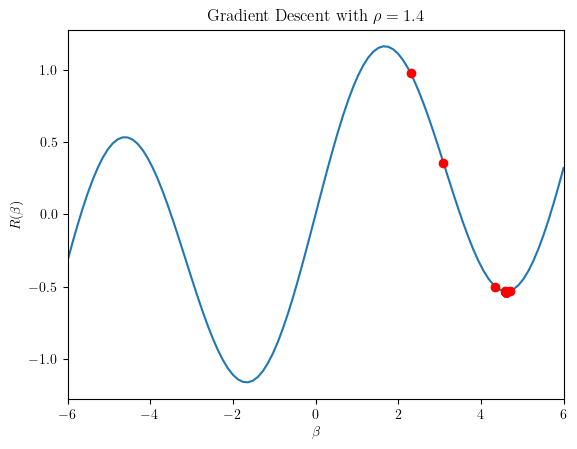

In [40]:
import numpy as np
import matplotlib.pyplot as plt

plt.rc('text', usetex=True)
plt.rc('font', family='serif')

fig, ax = plt.subplots()
ax.set_title(r'Gradient Descent with $\rho = 1.4$')
ax.set_xlabel(r'$\beta$')
ax.set_ylabel(r'$R(\beta)$')
ax.set_xlim(-6, 6)
x = np.linspace(-6, 6, 100)
y = np.sin(x) + x/10
ax.plot(x, y)

rho = 1.4

beta = [2.3]
beta_y = []
for i in range(100):
    beta.append(beta[i]-rho*(np.cos(beta[i])+1/10))
for b in beta:
    beta_y.append(np.sin(b) + b/10)
ax.plot(beta, beta_y, 'ro')
beta[100]

In [69]:
import torch
from torchinfo import summary
from torch.utils.data import TensorDataset
import pandas as pd
from torch import nn
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from sklearn.model_selection import train_test_split

class DefaultModel(nn.Module):
    def __init__(self , input_size):
        super(DefaultModel , self).__init__ ()
        self.flatten = nn.Flatten ()
        self.sequential = nn.Sequential(
            nn.Linear(input_size , 50),
            nn.ReLU(),
            nn.Dropout (0.4) ,
            nn.Linear (50, 1))
    def forward(self , x):
        x = self.flatten(x)
        return torch.flatten(self.sequential(x))
    
Default = load_data('Default').dropna()
n = Default.shape[0]

model = MS(Default.columns.drop('default'), intercept=False)
X = model.fit_transform(Default).to_numpy()
Y = Default['default'].to_numpy()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/3, random_state=42)

def_model = DefaultModel(X.shape[1])
summary(def_model ,
        input_size=X_train.shape, 
        col_names =['input_size',
                    'output_size',
                    'num_params'])

X_train_t = torch.tensor(X_train.astype(np.float32))
Y_train_t = torch.tensor(Y_train.astype(np.float32))
hit_train = TensorDataset(X_train_t , Y_train_t)

ValueError: could not convert string to float: 'No'